<a href="https://colab.research.google.com/github/abegyaberhanu/Abby-s_Portfolio/blob/main/Exercise_7_kc_house_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<Figure size 1200x600 with 0 Axes>

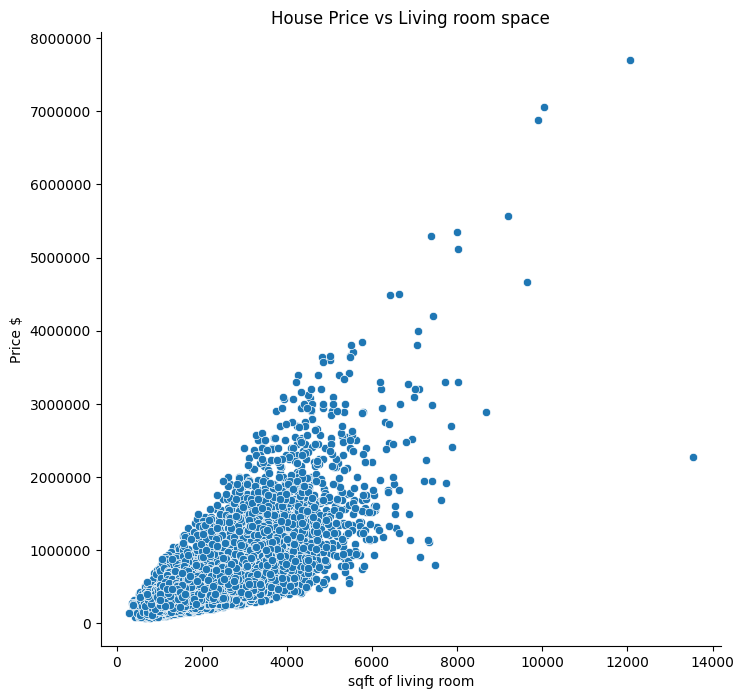

Intercept of the model: -48257.063591028214
Coefficient of the line: [283.96855716]
Mean Absolute Error: 170780.9262814558
Mean Squared Error: 61940787124.62475
Root Mean Squared Error: 248879.06124185046
r square : 0.47915772372653753


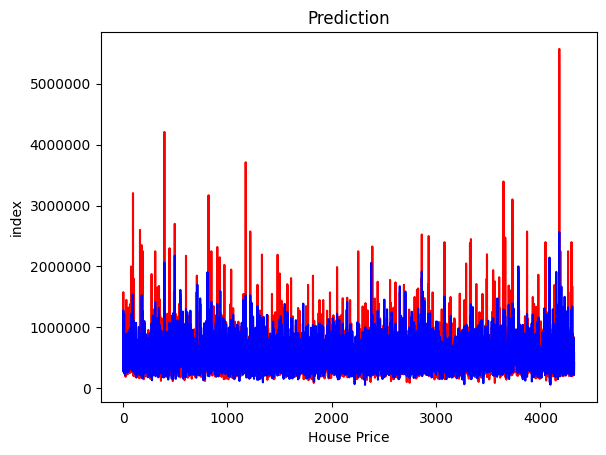

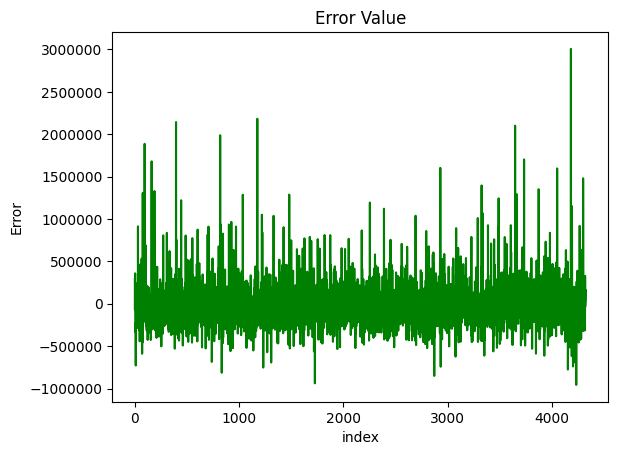

In [ ]:
# import all the libraries of code from python to reduce size of file and increase efficiency
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Import specific funtions from differnt libraries so we don't have to import whole
# libraries to reduce computational power needed
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# create a datafram object and input the datapoints from the file
# Because this object is different dementions, we are able to read whole
# files into the variable
data = pd.read_csv('/content/kc_house_data.csv')

# we selected the sqft of the living room as the independent variable that can
# influence the price of the house and we are just plotting the datapoints for
# the selected variables

#create a 12 x 6 graph
plt.figure(figsize=(12,6))
#specify the x and y variables and the type of graph
sns.pairplot(data,x_vars=['sqft_living'],y_vars=['price'],height=7,kind='scatter')

#lable the axes and the title of the graph
plt.xlabel('sqft of living room')
plt.ylabel('Price $')
plt.title('House Price vs Living room space')
#specify plain sytly becuase it defaults to scientific notation
plt.ticklabel_format(axis="y", style="plain")
#show the graph with the specified characteristics
plt.show()

#create and assign an independent variable with sqft_living
X = data[['sqft_living']]

#create and assign a dependent variable with the price of the houses
y = data['price']

# Python has a function that we imported that can slice the data we select into
# testing and traning data so the model is built on a portion of the data and
# then we test the built model with the rest of the data it hasn't seen to check
# for accuracy.
# Here we are specifying 80% of the datapoints randomly selected to be the
# Traning portion
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=0)

# build the linear regression model with the training datapoints selected randomly
# A linear regression model is basically a line of best fit that is trying to
# minimize the error gap between the actual datapoints and the line
# This line is going to be used to predict the price of houses based on the sqft
# of the living room of a house.
# We are traning a model with the portion of the datapoints selected
lr = LinearRegression()
lr.fit(X_train,y_train)

# We then create another variable to store the values of the model's predictions
# for the portion of datapoints set aside for testing the accuracy of the model
y_pred = lr.predict(X_test)

# This prints where the line of best fit created by the model intercepts the y axis
print('Intercept of the model:',lr.intercept_)
#This prints the slope of the line
print('Coefficient of the line:',lr.coef_)

# We are now going to test the accuracy of the model

# Accuracy metrics using one of the python libaries called scikit learn we
# imported earlier

# This measures the absolute average of the difference between the actual values
# of the test datapoints and what the model predicted
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))

# This also measures the difference between the line of best fit and the
# actual datapoints but squares them so it is sensetive to outliers
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))

# This also measures the difference between the line and the actual datapoints
# this is the standard deviation of the difference
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

#This is the R^2 of the model
# This variable measures the relationship between the independent and dependent variables
# This value is how much of the variation of the depenent variable is because
# of the independent variable
print('r square :' , metrics.r2_score(y_test, y_pred))


#This uses the same method of creating a visualization after going thoguh the
# test and predicted values from the model and the actual datapoints we know
# to be true
c = [i for i in range (1,len(y_test)+1,1)]
#This assignes the predicted values as blue and the actual datapoints as red so
# We can easily see the differenc betweeen the values
plt.plot(c,y_test,color='r',linestyle='-')
plt.plot(c,y_pred,color='b',linestyle='-')
plt.xlabel('House Price')
plt.ylabel('index')
plt.title('Prediction')
#specify plain sytly becuase it defaults to scientific notation
plt.ticklabel_format(axis="y", style="plain")
plt.show()

# plotting the error
#This creates the graph that plots all the datapoints and plots the difference
#between the test values we know to be true and the predictions made by the model
c = [i for i in range(1,len(y_test)+1,1)]
plt.plot(c,y_test-y_pred,color='green',linestyle='-')
plt.xlabel('index')
plt.ylabel('Error')
plt.title('Error Value')
#specify plain sytly becuase it defaults to scientific notation
plt.ticklabel_format(axis="y", style="plain")
plt.show()





•	Additional Questions:
o	How does the simple linear regression model results (using sqft_living) compare to the multiple regression we ran in the tutorial.  
In the tutorial, even though sqft_living comparatively is the best feature (of the three), in general the model only explained 54% of variation in house prices, while in this model, the accuracy went down to 48%. Even though it is not a huge differenct, it is still somthing to take note of.


o	Which model (which features) better capture the variation in y based on the variation in the feature(s)?  Justify your response based on output from your model(s).
The sqft of the living room is still the best feature compared to the tutorial because it has the highest value for expalining the variation in the house prices.